# Practical 07 — Feature Reduction with PCA

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Syllabus:** *Perform feature reduction using PCA and visualise the transformed features.*  
**Benchmark:** Wisconsin Breast Cancer — 30 numeric assays, binary `diagnosis`.

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG (path, features, q)
        ↓
[3] 4-point 2-D HAND table (center, Sigma, char. poly, unit v, scores)
        ↓
[4] Unsupervised PCA / eig vs SVD / reconstruction theory
        ↓
[5] NumPy PCA (eigh) ≡ sklearn PCA  →  [6] Scaler+PCA pipeline on 30-D cancer data
        ↓
[7] Scree, 2-D/3-D scores, loadings+biplot, classifier before/after  →  [8] Viva
```

### Learning outcomes

1. Mean-center four 2-D points; form \(\Sigma\); solve \(\det(\Sigma-\lambda I)=0\); recover unit \(v_1,v_2\).
2. Compute explained-variance ratios and 1-D scores \(z=X_c v_1\); match NumPy / sklearn.
3. State **unsupervised** PCA, **eigendecomposition vs SVD**, and **reconstruction MSE**.
4. Implement `NumpyPCA` with `np.linalg.eigh` asserted against `sklearn.decomposition.PCA`.
5. Fit a leakage-safe `Pipeline(StandardScaler, PCA)` on Breast Cancer; plot scree, scores, biplot, and a downstream classifier.

> **Why this matters:** PCA does not use labels. If you skip scaling, `mean area` (hundreds) swamps `mean smoothness` (\(\sim 0.1\)) and the first PC is “just size.”


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or set `COLAB_DRIVE_CSV`.
3. No file: `sklearn.datasets.load_breast_cancer`.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#1e3a8a") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#eff6ff;border-left:4px solid #1d4ed8;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    print(f"\n{bar}\n {title}\n{bar}" if title else bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──────────► Breast Cancer CSV (or yours)
  NUMERIC_FEATURES ───► columns to project (None = all numeric except the target)
  TARGET_COLUMN ──────► diagnosis / class (colour only — PCA never uses it)
  N_COMPONENTS ───────► q for the pipeline and 2-D / 3-D plots (scree still uses all)
  DROP_COLUMNS ───────► IDs to ignore
```

> **Why this matters:** \(q\) is a modelling choice, not a feature. Putting it in CONFIG makes the lab record say how many PCs you kept.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — swap CSV / features / q here                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/breast_cancer.csv"
TARGET_COLUMN = "diagnosis"          # why: labels colour plots; they never enter Sigma
NUMERIC_FEATURES = None              # None = every numeric column except the target
N_COMPONENTS = 2                     # why: 2-D scores / biplot; scree still uses all PCs
DROP_COLUMNS: list[str] = []

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH          = {DATA_PATH}")
print(f"TARGET_COLUMN      = {TARGET_COLUMN}")
print(f"NUMERIC_FEATURES   = {NUMERIC_FEATURES}")
print(f"N_COMPONENTS       = {N_COMPONENTS}")
print(f"DROP_COLUMNS       = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local CSV exists: {_p.is_file()}  ({_p.resolve() if _p.exists() else _p})")



 DATASET CONFIG
DATA_PATH          = data/breast_cancer.csv
TARGET_COLUMN      = diagnosis
NUMERIC_FEATURES   = None
N_COMPONENTS       = 2
DROP_COLUMNS       = []
local CSV exists: True  (D:\LiamCodes\parul-mtech-coding\ml-practical\07_PCA_Feature_Reduction\data\breast_cancer.csv)


## 0. Environment, seed, and large high-DPI figures


In [3]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # why: registers 3-D projection
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

SEED = 42  # why: split, solver, and timing must be repeatable for the lab record
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid", palette="colorblind")

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| sklearn PCA + Pipeline")
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | sklearn PCA + Pipeline
SEED = 42


## 1. Four-point 2-D toy — full hand calculation

Training matrix (\(n=4\), \(p=2\)):

$$
X=\begin{bmatrix}1&1\\2&3\\3&2\\4&4\end{bmatrix}.
$$

**Step 1 — mean and centering.** Sample mean \(\bar x=(2.5,\,2.5)\). Centered rows

$$
X_c=\begin{bmatrix}-1.5&-1.5\\-0.5&0.5\\0.5&-0.5\\1.5&1.5\end{bmatrix}.
$$

**Step 2 — sample covariance** (Bessel \(n-1=3\)):

$$
\Sigma=\frac{1}{3}X_c^\top X_c=\frac{1}{3}\begin{bmatrix}5&4\\4&5\end{bmatrix}
=\begin{bmatrix}5/3&4/3\\4/3&5/3\end{bmatrix}.
$$

**Step 3 — characteristic polynomial.**

$$
\det(\Sigma-\lambda I)=\Bigl(\tfrac{5}{3}-\lambda\Bigr)^2-\Bigl(\tfrac{4}{3}\Bigr)^2=0
\quad\Rightarrow\quad \lambda=\tfrac{5}{3}\pm\tfrac{4}{3}.
$$

$$
\lambda_1=3,\qquad \lambda_2=\tfrac13.
$$

**Step 4 — unit eigenvectors.** \((\Sigma-3I)v=0\) \(\Rightarrow\) \(v_1=\frac{1}{\sqrt{2}}(1,1)^\top\).  
\((\Sigma-\frac13 I)v=0\) \(\Rightarrow\) \(v_2=\frac{1}{\sqrt{2}}(1,-1)^\top\).

**Step 5 — ratios and 1-D scores.**

$$
\pi_1=\frac{3}{3+1/3}=\frac{9}{10},\qquad
\pi_2=\frac{1}{10},\qquad
z=X_c v_1=\bigl(-1.5\sqrt{2},\;0,\;0,\;1.5\sqrt{2}\bigr)^\top.
$$

sklearn `PCA` uses the same \(1/(n-1)\) covariance eigenvalues. Eigenvector **signs** may flip; we align them before comparing scores.


In [4]:
# 4-point toy — hand numbers vs NumPy vs sklearn
X_toy = np.array([[1.0, 1.0], [2.0, 3.0], [3.0, 2.0], [4.0, 4.0]])  # why: Sigma has closed-form lambdas 3 and 1/3
n_toy, p_toy = X_toy.shape
mu_hand = np.array([2.5, 2.5])
Xc_hand = X_toy - mu_hand
Sigma_hand = (Xc_hand.T @ Xc_hand) / (n_toy - 1)  # why: match sklearn explained_variance_ (n-1)
lam1_hand, lam2_hand = 3.0, 1.0 / 3.0
v1_hand = np.array([1.0, 1.0]) / np.sqrt(2.0)
v2_hand = np.array([1.0, -1.0]) / np.sqrt(2.0)
pi1_hand = lam1_hand / (lam1_hand + lam2_hand)
z1_hand = Xc_hand @ v1_hand

evals_np, evecs_np = np.linalg.eigh(Sigma_hand)  # why: symmetric -> eigh, not eig
order = np.argsort(evals_np)[::-1]
evals_np = evals_np[order]
evecs_np = evecs_np[:, order]


def _align_sign(v: np.ndarray, ref: np.ndarray) -> np.ndarray:
    return -v if np.dot(v, ref) < 0 else v  # why: eigenvectors are defined up to sign


v1_np = _align_sign(evecs_np[:, 0], v1_hand)
v2_np = _align_sign(evecs_np[:, 1], v2_hand)

pca_sk = PCA(n_components=2, svd_solver="full")  # why: full SVD is deterministic on this tiny X
pca_sk.fit(X_toy)
v1_sk = _align_sign(pca_sk.components_[0], v1_hand)
v2_sk = _align_sign(pca_sk.components_[1], v2_hand)
z1_sk = (X_toy - pca_sk.mean_) @ v1_sk

hand_table = pd.DataFrame(
    {
        "quantity": [
            "mu_x",
            "mu_y",
            "Sigma_11",
            "Sigma_12",
            "lambda_1",
            "lambda_2",
            "pi_1",
            "z_row0",
            "z_row3",
        ],
        "hand": [
            mu_hand[0],
            mu_hand[1],
            Sigma_hand[0, 0],
            Sigma_hand[0, 1],
            lam1_hand,
            lam2_hand,
            pi1_hand,
            z1_hand[0],
            z1_hand[3],
        ],
        "numpy": [
            X_toy.mean(0)[0],
            X_toy.mean(0)[1],
            Sigma_hand[0, 0],
            Sigma_hand[0, 1],
            evals_np[0],
            evals_np[1],
            evals_np[0] / evals_np.sum(),
            (Xc_hand @ v1_np)[0],
            (Xc_hand @ v1_np)[3],
        ],
        "sklearn": [
            pca_sk.mean_[0],
            pca_sk.mean_[1],
            np.nan,
            np.nan,
            pca_sk.explained_variance_[0],
            pca_sk.explained_variance_[1],
            pca_sk.explained_variance_ratio_[0],
            z1_sk[0],
            z1_sk[3],
        ],
    }
)
_banner("1 · 4-point toy")
display(hand_table.round(8))

assert np.allclose(X_toy.mean(0), mu_hand)
assert np.allclose(evals_np, [lam1_hand, lam2_hand])
assert np.allclose(v1_np, v1_hand) and np.allclose(v2_np, v2_hand)
assert np.allclose(pca_sk.explained_variance_, [lam1_hand, lam2_hand])
assert np.allclose(pca_sk.explained_variance_ratio_[0], pi1_hand)
assert np.allclose(z1_sk, z1_hand)
print("Hand = NumPy eigh = sklearn PCA  (eigenvalues, ratios, aligned 1-D scores).")
_why(
    "Closed-form lambdas (3 and 1/3) let a viva examiner ask you to expand "
    "det(Sigma - lambda I) on the board — then the notebook proves you did not invent the numbers."
)


,quantity,hand,numpy,sklearn
0,mu_x,2.500000,2.500000,2.500000
1,mu_y,2.500000,2.500000,2.500000
2,Sigma_11,1.666667,1.666667,NaN
3,Sigma_12,1.333333,1.333333,NaN
4,lambda_1,3.000000,3.000000,3.000000
5,lambda_2,0.333333,0.333333,0.333333
6,pi_1,0.900000,0.900000,0.900000
7,z_row0,-2.121320,-2.121320,-2.121320
8,z_row3,2.121320,2.121320,2.121320


Hand = NumPy eigh = sklearn PCA  (eigenvalues, ratios, aligned 1-D scores).


## 2. Theory — unsupervised reduction, eig vs SVD, reconstruction

### 2.1 Unsupervised linear compression

Given standardized (or at least **centered**) \(X\in\mathbb{R}^{n\times p}\), PCA finds an orthonormal \(W_q\in\mathbb{R}^{p\times q}\) that **maximises captured variance** of the scores \(Z=X_c W_q\). Class labels never enter \(W_q\). Colouring a scatter plot by diagnosis is visualisation, not supervision.

### 2.2 Eigendecomposition of the covariance

With Bessel correction (sklearn `explained_variance_`):

$$
\Sigma=\frac{1}{n-1}X_c^\top X_c,\qquad
\Sigma w=\lambda w,\qquad
\lambda_1\ge\cdots\ge\lambda_p\ge 0.
$$

\(\lambda_j=\mathrm{Var}(z_{\cdot j})\). Ratios \(\pi_j=\lambda_j/\sum_k\lambda_k\), cumulative \(\Pi_q=\sum_{j=1}^q\pi_j\).

**Elbow:** a knee in \(\pi_j\). **95% rule:** smallest \(q\) with \(\Pi_q\ge 0.95\).

**Bias–variance intuition (informal):** small \(q\) throws away signal (underfit the cloud); large \(q\) keeps noise. PCA itself is not a classifier — the tradeoff appears in the **downstream** model.

### 2.3 SVD (what sklearn uses)

$$
X_c=U S V^\top,\qquad
w_j=v_j,\qquad
\lambda_j=\frac{s_j^2}{n-1}.
$$

For a **symmetric PSD** \(\Sigma\), `eigh` and this SVD agree on \(\lambda_j\) (and on \(w_j\) up to sign). SVD is numerically preferred for \(n\neq p\) and is how `sklearn.decomposition.PCA` is implemented.

### 2.4 Reconstruction loss

$$
\hat X_c=Z_q W_q^\top=X_c W_q W_q^\top,\qquad
\mathrm{MSE}=\frac{1}{np}\|X_c-\hat X_c\|_F^2=\frac{1}{p}\sum_{j=q+1}^{p}\lambda_j\cdot\frac{n-1}{n}
$$

(up to the \(n\) vs \(n-1\) convention). \(q=p\) recovers \(X_c\) (full rank). **Never** fit the scaler or PCA on the test set — that leaks test moments into \(W\).

> **Why this matters:** reconstruction error falling with \(q\) is **not** proof that the PCs are medically meaningful. It only says the linear subspace fits the cloud.


## 3. Vectorized NumPy `NumpyPCA` (must match sklearn)


In [5]:
class NumpyPCA:
    """Centered PCA via covariance eigh. Matches sklearn eigenvalues and scores (signs aligned)."""

    def __init__(self, n_components: int | None = None):
        self.n_components = n_components  # why: None = keep all p columns

    def fit(self, X: np.ndarray) -> "NumpyPCA":
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)  # why: sklearn also subtracts the column mean
        Xc = X - self.mean_
        n = Xc.shape[0]
        cov = (Xc.T @ Xc) / (n - 1)  # why: sklearn explained_variance_ uses n-1
        evals, evecs = np.linalg.eigh(cov)
        idx = np.argsort(evals)[::-1]
        evals, evecs = evals[idx], evecs[:, idx]
        q = X.shape[1] if self.n_components is None else int(self.n_components)
        self.components_ = evecs[:, :q].T  # why: sklearn stores PCs as rows
        self.explained_variance_ = evals[:q]
        tot = evals.sum()
        self.explained_variance_ratio_ = evals[:q] / tot
        self.singular_values_ = np.sqrt(evals[:q] * (n - 1))
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (np.asarray(X, dtype=float) - self.mean_) @ self.components_.T

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        return np.asarray(Z, dtype=float) @ self.components_ + self.mean_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


# Prove agreement on the toy (signs aligned)
np_pca = NumpyPCA(n_components=2).fit(X_toy)
sk_pca = PCA(n_components=2, svd_solver="full").fit(X_toy)
assert np.allclose(np_pca.explained_variance_, sk_pca.explained_variance_)
assert np.allclose(np_pca.explained_variance_ratio_, sk_pca.explained_variance_ratio_)
Z_np = np_pca.transform(X_toy)
Z_sk = sk_pca.transform(X_toy)
for j in range(2):
    if np.dot(Z_np[:, j], Z_sk[:, j]) < 0:
        Z_np[:, j] *= -1
assert np.allclose(Z_np, Z_sk)
X_rec = np_pca.inverse_transform(np_pca.transform(X_toy))
assert np.allclose(X_rec, X_toy, atol=1e-10)
print("NumpyPCA == sklearn PCA on the 4-point toy (variance, aligned scores, full reconstruction).")


NumpyPCA == sklearn PCA on the 4-point toy (variance, aligned scores, full reconstruction).


## 4. Load Breast Cancer from CONFIG

| Priority | Source |
|----------|--------|
| 1 | `DATA_PATH` |
| 2 | Colab Drive / upload |
| 3 | `sklearn.datasets.load_breast_cancer` |


In [6]:
def _resolve_csv(path_str: str) -> Path | None:
    p = Path(path_str)
    if p.is_file():
        return p
    if IN_COLAB and COLAB_DRIVE_CSV:
        root = colab_mount_drive()
        cand = Path(COLAB_DRIVE_CSV) if Path(COLAB_DRIVE_CSV).is_file() else (
            (root / COLAB_DRIVE_CSV) if root else None
        )
        if cand is not None and cand.is_file():
            return cand
    if IN_COLAB and COLAB_OFFER_UPLOAD:
        up = colab_upload_to(Path(path_str))
        if up is not None and up.is_file():
            return up
    return None


def load_table() -> pd.DataFrame:
    csv_path = _resolve_csv(DATA_PATH)
    if csv_path is not None:
        df = pd.read_csv(csv_path)
        print(f"Loaded CSV: {csv_path}  shape={df.shape}")
        return df
    bunch = load_breast_cancer(as_frame=True)
    df = bunch.frame.rename(columns={"target": TARGET_COLUMN})
    # sklearn target is 0/1; map to names used in the local CSV
    df[TARGET_COLUMN] = df[TARGET_COLUMN].map({0: "malignant", 1: "benign"})
    print("Fallback: sklearn load_breast_cancer  shape=", df.shape)
    return df


df_raw = load_table()
for c in DROP_COLUMNS:
    if c in df_raw.columns:
        df_raw = df_raw.drop(columns=c)

if TARGET_COLUMN not in df_raw.columns:
    raise ValueError(f"TARGET_COLUMN={TARGET_COLUMN!r} not in columns {list(df_raw.columns)}")

y_text = df_raw[TARGET_COLUMN].astype(str)
if NUMERIC_FEATURES is None:
    feat_cols = [
        c
        for c in df_raw.columns
        if c != TARGET_COLUMN and pd.api.types.is_numeric_dtype(df_raw[c])
    ]
else:
    feat_cols = list(NUMERIC_FEATURES)

X_all = df_raw[feat_cols].to_numpy(dtype=float)
le = LabelEncoder()
y_all = le.fit_transform(y_text)

_banner("4 · Data")
print(f"n={X_all.shape[0]}  p={X_all.shape[1]}  classes={list(le.classes_)}")
print("features:", feat_cols[:8], "..." if len(feat_cols) > 8 else "")
display(df_raw[feat_cols[:6] + [TARGET_COLUMN]].head())
_why(
    "Thirty correlated size/shape assays live on different scales. PCA after StandardScaler "
    "turns that collinearity into a few PCs instead of letting area dominate every distance."
)


Loaded CSV: data\breast_cancer.csv  shape=(569, 31)


n=569  p=30  classes=['benign', 'malignant']
features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points'] ...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,malignant


## 5. Leakage-safe split + `StandardScaler` then PCA

Fit **mean and scale on the training fold only**. Transform validation/test with those statistics. PCA is then fit on **scaled train** \(X_{\mathrm{tr}}\).


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.25,
    random_state=SEED,
    stratify=y_all,  # why: keep malignant/benign ratio in both folds
)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)  # why: fit NEVER sees X_test
Xte_s = scaler.transform(X_test)

q_cfg = int(N_COMPONENTS)
q_cfg = max(1, min(q_cfg, Xtr_s.shape[1]))

np_full = NumpyPCA(n_components=None).fit(Xtr_s)
sk_full = PCA(svd_solver="full", random_state=SEED).fit(Xtr_s)
assert np.allclose(np_full.explained_variance_, sk_full.explained_variance_, rtol=1e-6, atol=1e-8)
print("Train-fold NumpyPCA eigenvalues match sklearn (rtol=1e-6).")

pipe_pca = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=q_cfg, svd_solver="full", random_state=SEED)),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]
)  # why: one object so test rows cannot leak into scaler or PCA
print(f"CONFIG N_COMPONENTS q={q_cfg}  |  train n={len(y_train)}  test n={len(y_test)}")


Train-fold NumpyPCA eigenvalues match sklearn (rtol=1e-6).
CONFIG N_COMPONENTS q=2  |  train n=426  test n=143


## 6. Scree plot and cumulative explained variance (elbow + 95%)


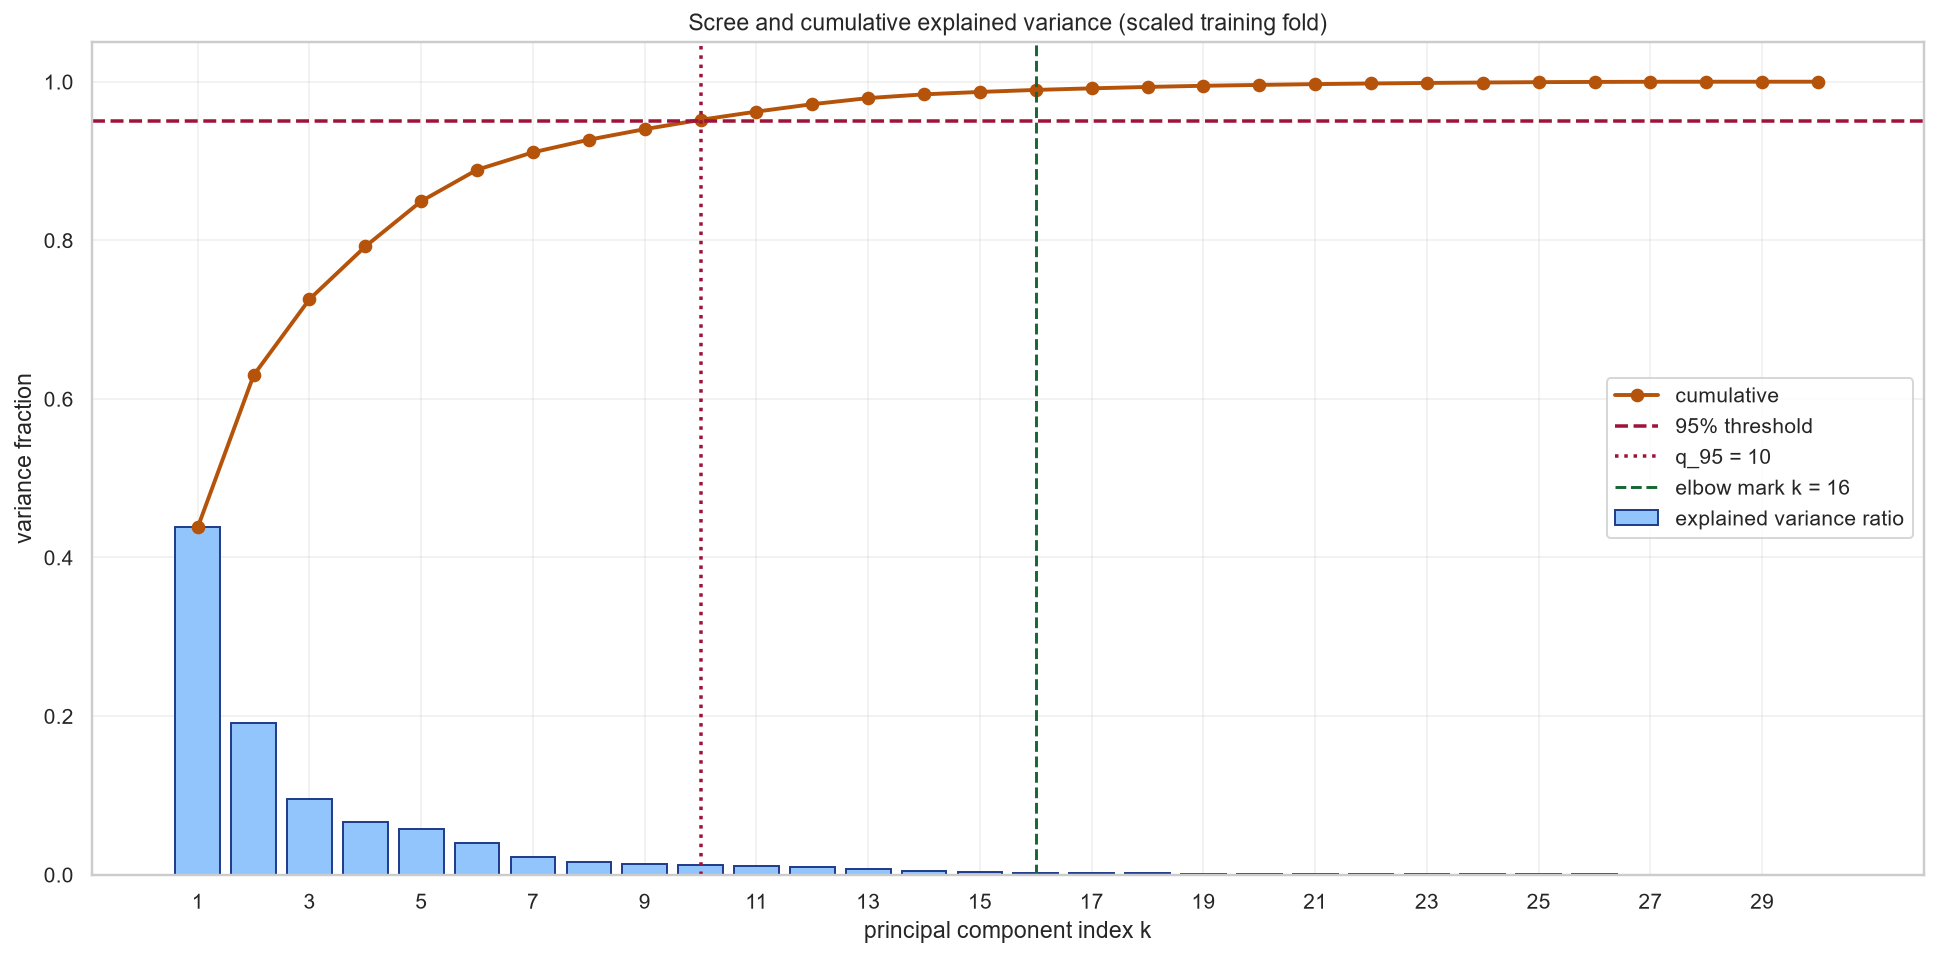

q for 95% variance = 10   cumulative at q_cfg=2: 0.6298


In [8]:
ratios = sk_full.explained_variance_ratio_
cum = np.cumsum(ratios)
q95 = int(np.searchsorted(cum, 0.95) + 1)  # why: smallest q with Pi_q >= 0.95
# crude elbow: last k where drop from k-1 to k exceeds median drop
drops = np.diff(ratios)
thr = np.median(np.abs(drops))
elbow_candidates = np.where(np.abs(drops) >= thr)[0]
q_elbow = int(elbow_candidates[-1] + 1) if len(elbow_candidates) else 2

fig, ax = plt.subplots(figsize=(14, 7))
ks = np.arange(1, len(ratios) + 1)
ax.bar(ks, ratios, color="#93c5fd", edgecolor="#1e3a8a", label="explained variance ratio")
ax.plot(ks, cum, color="#b45309", marker="o", lw=2, label="cumulative")
ax.axhline(0.95, color="#9f1239", ls="--", lw=1.8, label="95% threshold")
ax.axvline(q95, color="#9f1239", ls=":", lw=1.8, label=f"q_95 = {q95}")
ax.axvline(q_elbow, color="#166534", ls="--", lw=1.5, label=f"elbow mark k = {q_elbow}")
ax.set_xlabel("principal component index k")
ax.set_ylabel("variance fraction")
ax.set_title("Scree and cumulative explained variance (scaled training fold)")
ax.set_xticks(ks[::2] if len(ks) > 16 else ks)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()
print(f"q for 95% variance = {q95}   cumulative at q_cfg={q_cfg}: {cum[q_cfg-1]:.4f}")
_why(
    "The 95% line is a convention, not a law. Quote both the elbow and q_95 in the viva, "
    "then justify the q you actually fed to the classifier."
)


## 7. 2-D and 3-D PCA score plots (class colour is display-only)


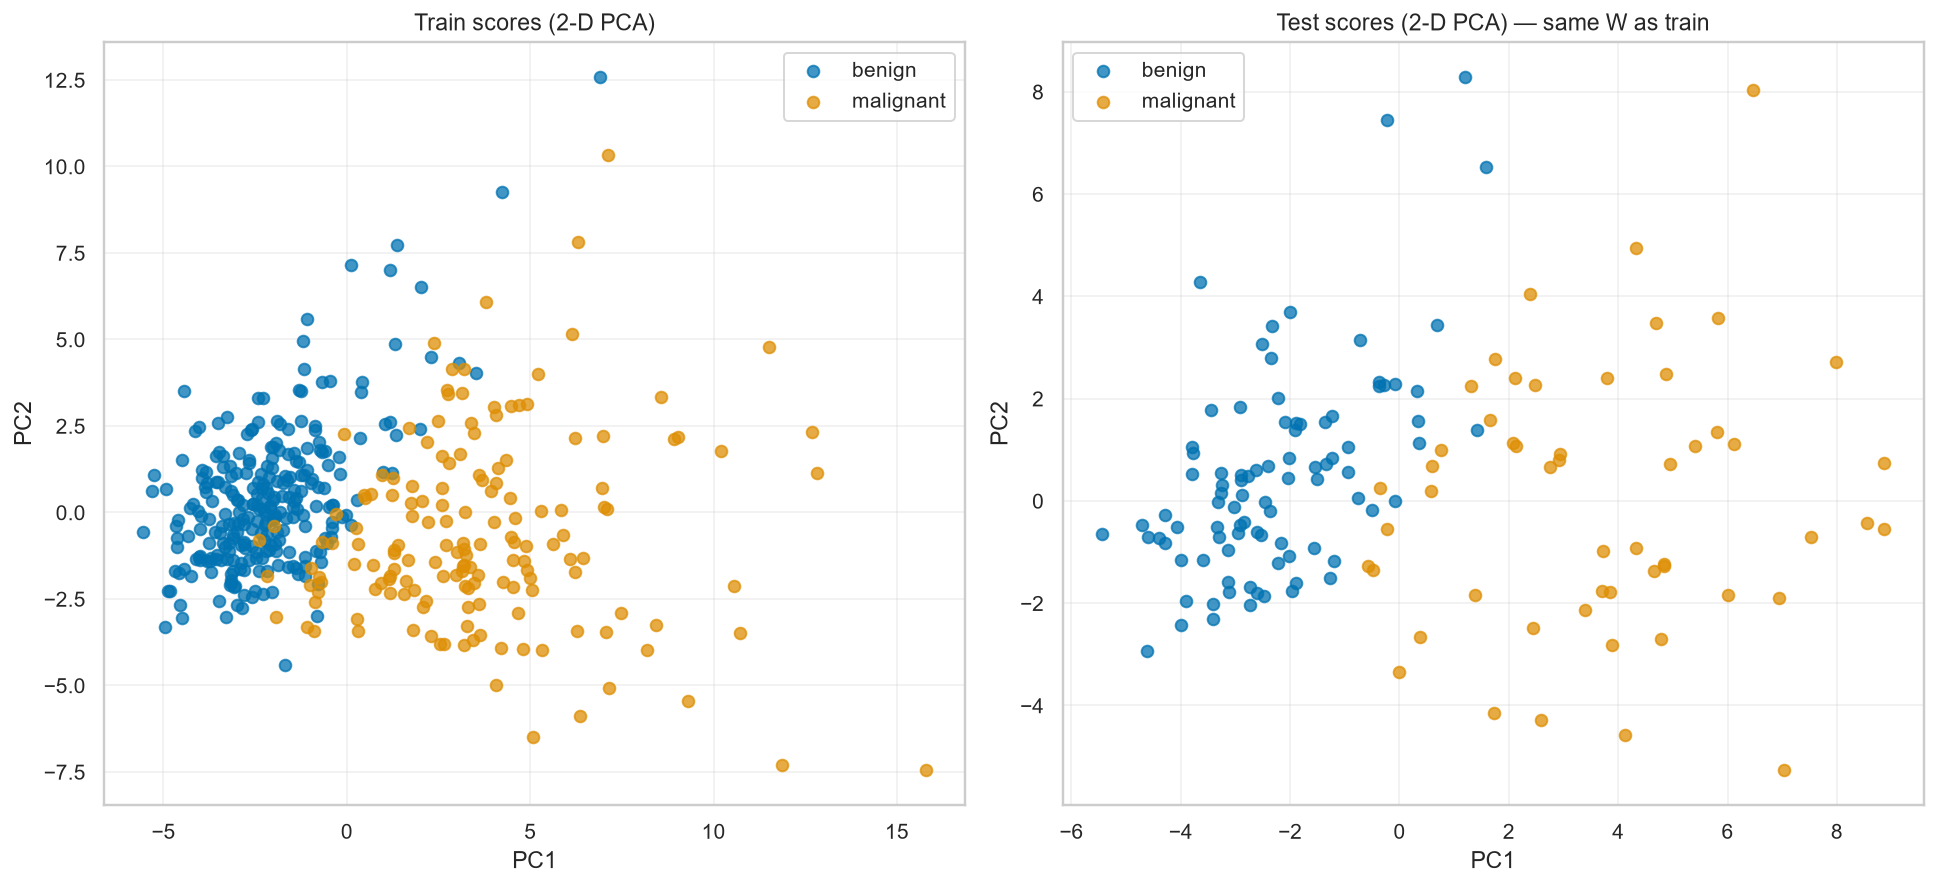

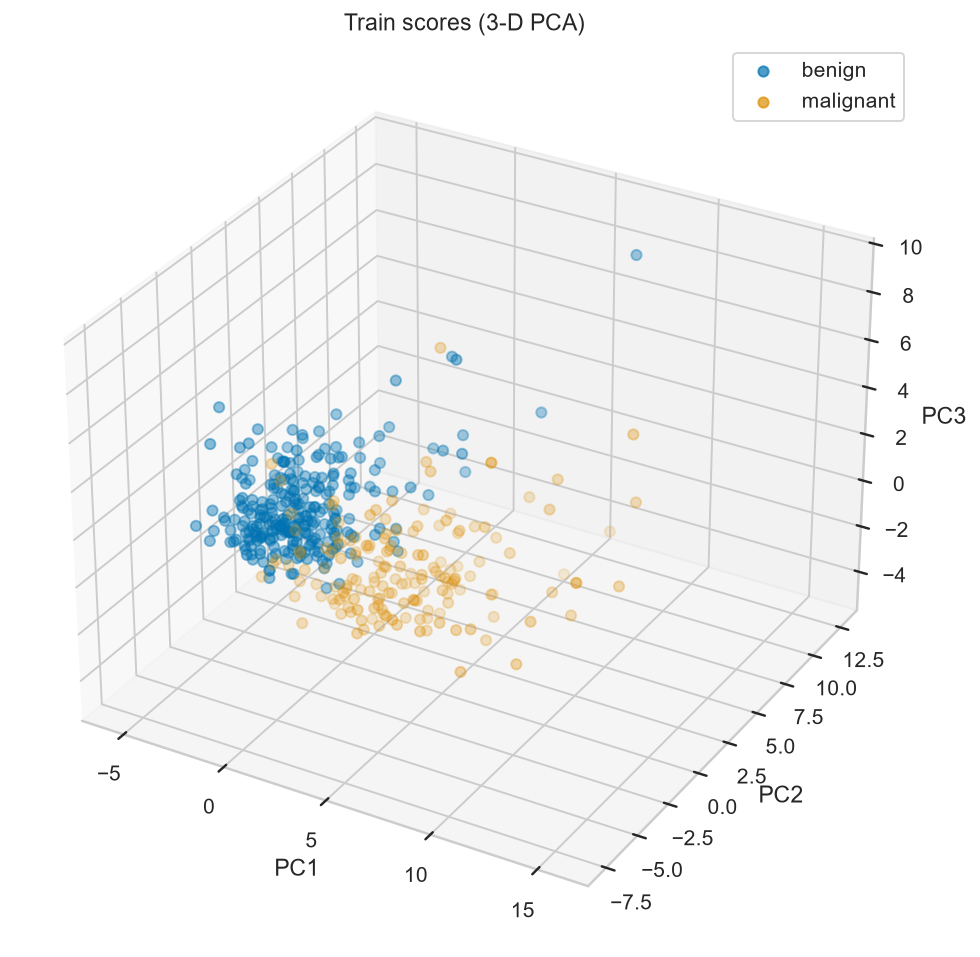

2-D variance captured: 0.630 | 3-D: 0.726


In [9]:
pca2 = PCA(n_components=2, svd_solver="full", random_state=SEED).fit(Xtr_s)
Ztr2 = pca2.transform(Xtr_s)
Zte2 = pca2.transform(Xte_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, Z, y, title in (
    (axes[0], Ztr2, y_train, "Train scores (2-D PCA)"),
    (axes[1], Zte2, y_test, "Test scores (2-D PCA) — same W as train"),
):
    for lab_i, name in enumerate(le.classes_):
        m = y == lab_i
        ax.scatter(Z[m, 0], Z[m, 1], s=36, alpha=0.75, label=name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
plt.show()

pca3 = PCA(n_components=3, svd_solver="full", random_state=SEED).fit(Xtr_s)
Ztr3 = pca3.transform(Xtr_s)
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection="3d")
for lab_i, name in enumerate(le.classes_):
    m = y_train == lab_i
    ax.scatter(Ztr3[m, 0], Ztr3[m, 1], Ztr3[m, 2], s=28, alpha=0.7, label=name)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Train scores (3-D PCA)")
ax.legend()
fig.tight_layout()
plt.show()
print(
    "2-D variance captured:",
    f"{pca2.explained_variance_ratio_.sum():.3f}",
    "| 3-D:",
    f"{pca3.explained_variance_ratio_.sum():.3f}",
)


## 8. Loadings heatmap and 2-D biplot

Loading of feature \(j\) on PC \(k\) is \(W_{jk}\) (sklearn `components_[k, j]`). A **biplot** draws score points and arrows \(c\cdot (W_{1j},W_{2j})\) for a few high-norm features.


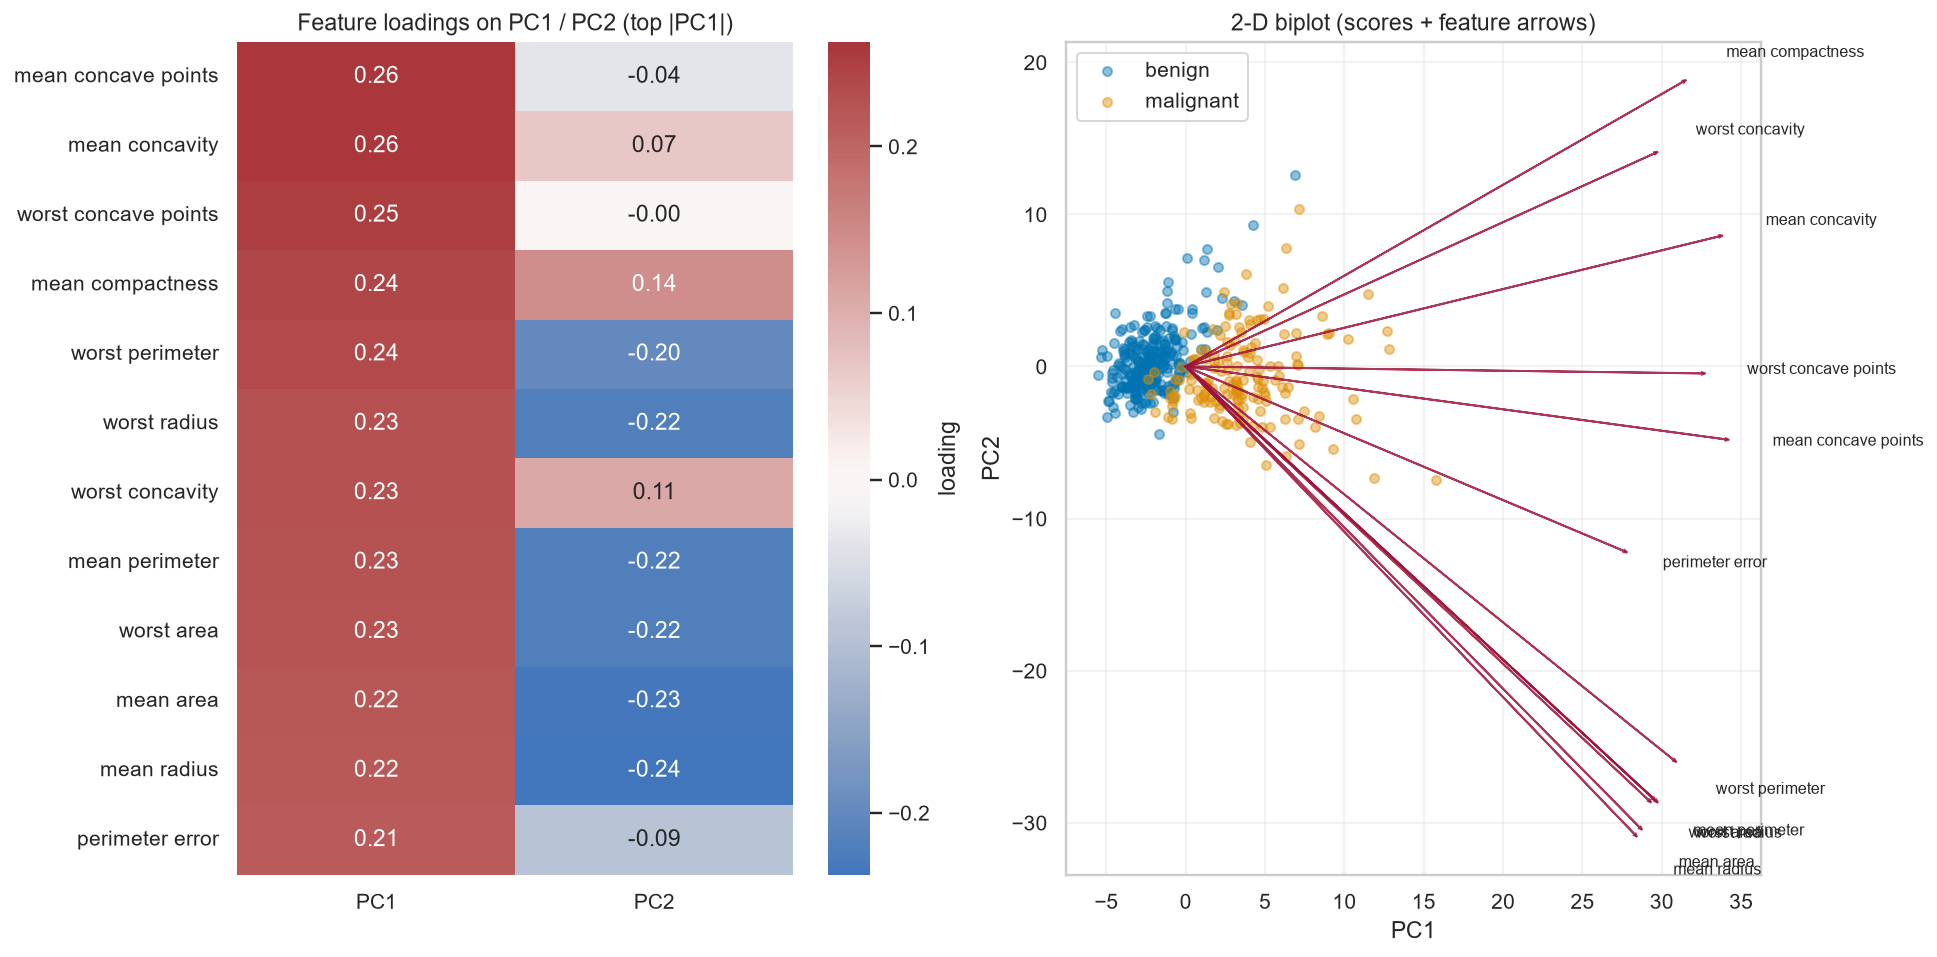

In [10]:
W = pca2.components_  # shape (2, p)
loadings = pd.DataFrame(W.T, index=feat_cols, columns=["PC1", "PC2"])
# heatmap of top-|PC1| features so the figure stays readable
top_idx = np.argsort(np.abs(loadings["PC1"]).to_numpy())[::-1][:12]
load_top = loadings.iloc[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.heatmap(
    load_top,
    ax=axes[0],
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "loading"},
)
axes[0].set_title("Feature loadings on PC1 / PC2 (top |PC1|)")

# biplot
ax = axes[1]
for lab_i, name in enumerate(le.classes_):
    m = y_train == lab_i
    ax.scatter(Ztr2[m, 0], Ztr2[m, 1], s=22, alpha=0.45, label=name)
arrow_scale = 3.0 * np.max(np.abs(Ztr2)) / (np.max(np.abs(W)) + 1e-12)
shown = loadings.reindex(load_top.index)
for name, row in shown.iterrows():
    ax.arrow(
        0,
        0,
        row["PC1"] * arrow_scale,
        row["PC2"] * arrow_scale,
        color="#9f1239",
        alpha=0.85,
        head_width=0.15,
        length_includes_head=True,
    )
    ax.text(row["PC1"] * arrow_scale * 1.08, row["PC2"] * arrow_scale * 1.08, name, fontsize=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("2-D biplot (scores + feature arrows)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()
_why(
    "A long arrow means that assay contributes strongly to that PC. Collinear arrows "
    "(radius / perimeter / area) are the geometric picture of multicollinearity."
)


## 9. Downstream classifier: time and accuracy before vs after PCA


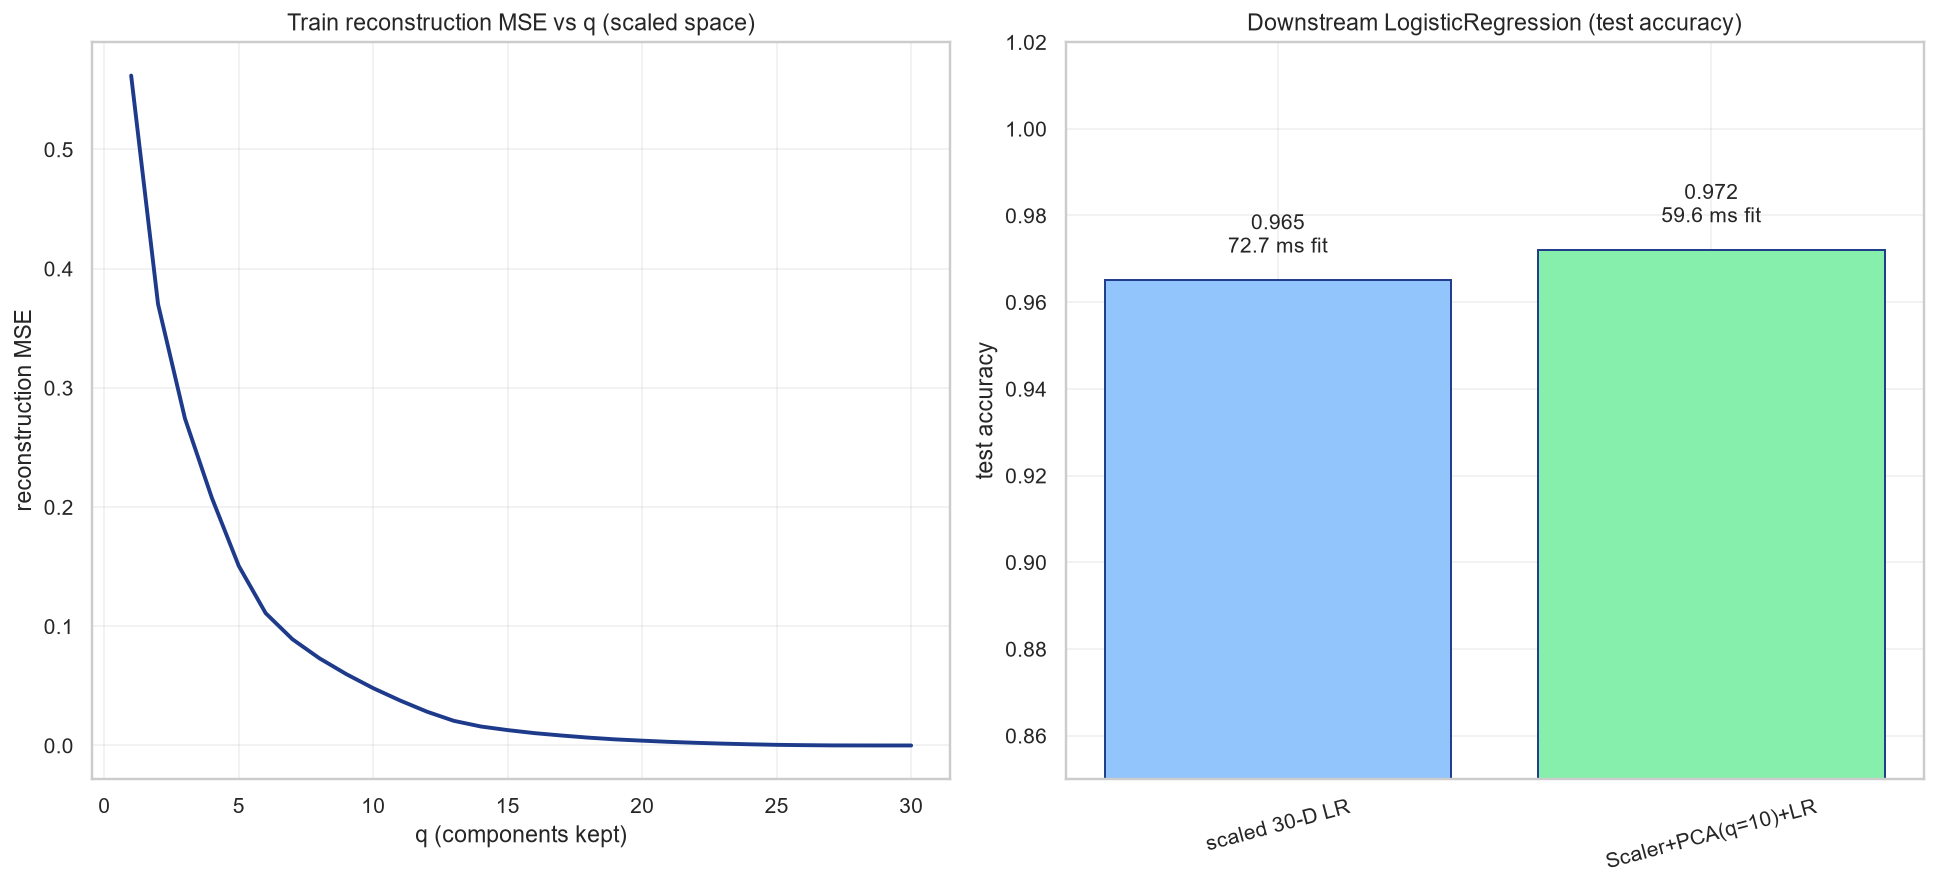

,model,test_accuracy,fit_seconds,n_features_in_clf
0,scaled 30-D LR,0.965035,0.072684,30
1,Scaler+PCA(q=10)+LR,0.972028,0.059566,10


CONFIG q=2 used in the 2-D plots; classifier PCA used q_down=10 (max of CONFIG and q_95).


In [11]:
clf_raw = LogisticRegression(max_iter=2000, random_state=SEED)
t0 = time.perf_counter()
clf_raw.fit(Xtr_s, y_train)  # already scaled train; no extra scaler leak
t_raw = time.perf_counter() - t0
acc_raw = accuracy_score(y_test, clf_raw.predict(Xte_s))

q_down = max(q_cfg, min(q95, Xtr_s.shape[1]))  # why: fair compression vs 95% rule
pipe_down = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=q_down, svd_solver="full", random_state=SEED)),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]
)
t1 = time.perf_counter()
pipe_down.fit(X_train, y_train)
t_pca = time.perf_counter() - t1
acc_pca = accuracy_score(y_test, pipe_down.predict(X_test))

# reconstruction MSE vs q on scaled train (NumpyPCA)
qs = list(range(1, Xtr_s.shape[1] + 1))
mse = []
n_, p_ = Xtr_s.shape
for q in qs:
    m = NumpyPCA(n_components=q).fit(Xtr_s)
    rec = m.inverse_transform(m.transform(Xtr_s))
    mse.append(np.mean((Xtr_s - rec) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
axes[0].plot(qs, mse, color="#1e3a8a", lw=2)
axes[0].set_xlabel("q (components kept)")
axes[0].set_ylabel("reconstruction MSE")
axes[0].set_title("Train reconstruction MSE vs q (scaled space)")

labels_b = ["scaled 30-D LR", f"Scaler+PCA(q={q_down})+LR"]
axes[1].bar([0, 1], [acc_raw, acc_pca], color=["#93c5fd", "#86efac"], edgecolor="#1e3a8a")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels_b, rotation=15)
axes[1].set_ylabel("test accuracy")
axes[1].set_ylim(0.85, 1.02)
axes[1].set_title("Downstream LogisticRegression (test accuracy)")
for i, (a, t) in enumerate(((acc_raw, t_raw), (acc_pca, t_pca))):
    axes[1].text(i, a + 0.005, f"{a:.3f}\n{t*1000:.1f} ms fit", ha="center", va="bottom", fontsize=11)
fig.tight_layout()
plt.show()

bench = pd.DataFrame(
    {
        "model": labels_b,
        "test_accuracy": [acc_raw, acc_pca],
        "fit_seconds": [t_raw, t_pca],
        "n_features_in_clf": [Xtr_s.shape[1], q_down],
    }
)
display(bench.round(6))
print(f"CONFIG q={q_cfg} used in the 2-D plots; classifier PCA used q_down={q_down} (max of CONFIG and q_95).")
_why(
    "A slightly lower accuracy after PCA can still be a win if q << p (faster models, less noise). "
    "Fit time here is tiny; the lesson is the protocol, not the milliseconds."
)


## 10. Viva voce — 12 questions

**Q1.** PCA uses the diagnosis column. True or false?  
**A1.** False. PCA is unsupervised; labels only colour the scatter.

**Q2.** Write \(\Sigma\) for the 4-point toy and the characteristic equation.  
**A2.** \(\Sigma=\begin{bmatrix}5/3&4/3\\4/3&5/3\end{bmatrix}\), \(\lambda=5/3\pm 4/3\) so \(\lambda_1=3\), \(\lambda_2=1/3\).

**Q3.** Why \(\pi_1=0.9\) on the toy?  
**A3.** \(3/(3+1/3)=9/10\).

**Q4.** Why `StandardScaler` before PCA on Breast Cancer?  
**A4.** Area and smoothness have incompatible units; Euclidean / covariance is not scale-invariant.

**Q5.** `eigh` vs `eig` vs SVD?  
**A5.** \(\Sigma\) is symmetric PSD \(\Rightarrow\) `eigh`. sklearn uses SVD of \(X_c\); \(\lambda_j=s_j^2/(n-1)\).

**Q6.** Why may `components_` signs disagree with your hand \(v_1\)?  
**A6.** Eigenvectors are defined up to sign; scores flip together. Align with a dot product.

**Q7.** What leaks if you scale on the full dataset then split?  
**A7.** Test-set means and variances enter \(\Sigma\) and \(W\).

**Q8.** Reconstruction MSE at \(q=p\)?  
**A8.** \(\approx 0\) (full-rank centered data).

**Q9.** Elbow vs 95% rule — which is “correct”?  
**A9.** Neither is unique. Report both; choose \(q\) for the **downstream** task.

**Q10.** Is a biplot a supervised plot?  
**A10.** No. Arrows are loadings; colour is optional annotation.

**Q11.** Relate discarded \(\lambda_{q+1},\ldots,\lambda_p\) to reconstruction.  
**A11.** Lost variance lives in the trailing eigenvalues; MSE falls as those terms are kept.

**Q12.** After PCA, LogisticRegression is still linear in the **original** \(x\). True?  
**A12.** It is linear in the **scores** \(z=W^\top(x-\mu)\), hence linear in \(x\) (affine). PCA+LR is still a linear classifier in input space.


## 11. Lab close

You centered a 4-point cloud, solved \(\det(\Sigma-\lambda I)=0\) by hand, matched `NumpyPCA` to sklearn, and compressed 30 scaled assays with a **train-only** scaler. Quote **test** accuracy at the \(q\) you chose — not the reconstruction MSE alone.
